# BEoRN: 21-cm Signal from Native density (LPT) and haloes (CHMF)

This tutorial models the 21-cm brightness-temperature signal from the Epoch of
Reionization with BEoRN's built-in cosmological engines — **no external
simulation code is required**:

- **`beorn.lpt`** — Lagrangian Perturbation Theory (ZA / 2LPT / 3LPT) density
  and velocity fields from an Eisenstein & Hu linear power spectrum.
- **`beorn.lpt.CHMFSampler`** — per-cell Poisson sampling of the Extended
  Press–Schechter *conditional* halo mass function, conditioned on the local
  LPT linear overdensity.
- **`LPTHaloLoader`** — exposes both to the standard BEoRN painting pipeline
  (1D radiation profiles, `PaintingCoordinator`, statistics, lightcones).

The cosmological building blocks are introduced and validated step by step in
two companion tutorials: `ps_hmf_models.ipynb` (linear $P(k)$, growth factor,
HMF models) and `lpt_chmf.ipynb` (LPT fields, conditional-HMF halo catalogues,
GPU and autodiff tests).

**Sections**
1. [Simulation and astrophysical parameters](#sec1)
2. [Radiation profiles](#sec2)
3. [Cosmological inputs: LPT density field + CHMF halo catalogues](#sec3)
4. [Halo catalogue and density field](#sec4)
5. [Painting the 3D signal maps](#sec5)
6. [Maps at a single redshift](#sec6)
7. [Global history and power spectra](#sec7)
8. [Lightcone](#sec8)

**Output:** results are saved under `./output/`, cached profile computations
under `./cache/`.


In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [2]:
FILE_ROOT = Path(".")
CACHE_ROOT = FILE_ROOT / "cache"
OUTPUT_ROOT = FILE_ROOT / "output" 

In [ ]:
import beorn

import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.titlesize': 14,
})

INFO:numexpr.utils:Note: detected 288 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
INFO:numexpr.utils:Note: NumExpr detected 288 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO:numexpr.utils:NumExpr defaulting to 16 threads.


In [ ]:
# Optional GPU backend detection (used by the GPU test in section 3)
try:
    import torch
    _TORCH_AVAILABLE = True
    torch_gpu = ('cuda' if torch.cuda.is_available()
                 else 'mps' if torch.backends.mps.is_available() else None)
    print(f'torch {torch.__version__} — GPU device: {torch_gpu or "none"}')
    if torch_gpu is None:
        print('GPUs not available — the GPU test will report this and continue.')
except ImportError:
    _TORCH_AVAILABLE = False
    torch_gpu = None
    print('torch is not installed — the GPU test will be skipped.')


torch 2.13.0+cu130 — GPU device: cuda


---
<a id="sec1"></a>
## 1. Set simulation and astrophysical parameters

Native-pipeline specifics:

- **Mesh-independent halo masses**: halo abundances come from the analytical
  conditional mass function evaluated in every cell — not from finding peaks
  on a grid — so the sampler resolves halos down to `source.halo_mass_min`
  regardless of `Ncell`.
- **Environment mass cap `M_env`**: the conditional HMF is only defined for
  halos lighter than the mass contained in the conditioning region. With the
  default cell-based conditioning, `M_env = rho_m * (Lbox/Ncell)^3` — for
  `Lbox=100 Mpc/h`, `Ncell=128` this is a few × 10^10 Msun, so the rare
  massive halos are truncated. Pass `R_env` (in Mpc/h) to `LPTHaloLoader` to
  condition on a larger smoothed region and extend the mass range.
- **`cosmo_sim.random_seed`** seeds the LPT Gaussian ICs (fixed-amplitude by
  default; a negative seed gives the paired realisation).


In [ ]:
parameters = beorn.structs.Parameters()

## Simulation grid
parameters.simulation.Ncell = 128               # grid — fast enough for development
parameters.simulation.Lbox  = 100               # Mpc/h
parameters.simulation.use_hunits = True         # Lbox above is in Mpc/h, not physical Mpc
parameters.simulation.oversample = 1            # explicit default: no fine-paint-then-downsample (see LPTBase.get_density)
parameters.simulation.mass_assignment = 'CIC'   # explicit default: use the CIC mass-assignment window for painting
parameters.simulation.backend.default = 'jax'   # explicit default: keeps this as the numpy reference used throughout for numpy-vs-jax/torch comparisons below

## Cosmo-sim inputs
parameters.cosmo_sim.random_seed = 12345
parameters.cosmo_sim.snapshot_redshifts = np.arange(20, 5, -0.50)    # coarser snapshot grid

## Solver: profile redshift grid and halo mass/accretion bins
parameters.solver.redshifts                = np.arange(20, 5, -0.25) # fine profile grid
parameters.solver.halo_mass_bin_min        = 1e7
parameters.solver.halo_mass_bin_max        = 1e15
parameters.solver.halo_mass_nbin           = 40
parameters.solver.halo_mass_accretion_alpha = np.array([0.785, 0.795])

# Source age: how far back to integrate the emission history.
parameters.solver.z_source_start  = 35.0  # default
parameters.source.t_source_age    = None  # default (no age cap)

## Cosmology
parameters.cosmology.Om = 0.315
parameters.cosmology.Ob = 0.049
parameters.cosmology.Ol = 1-0.315
parameters.cosmology.h0  = 0.673

## Source parameters
# X-ray emission
parameters.source.energy_cutoff_min_xray = 500
parameters.source.energy_cutoff_max_xray = 10000
parameters.source.energy_min_sed_xray = 200
parameters.source.energy_max_sed_xray = 10000
parameters.source.alS_xray = 1.5
parameters.source.xray_normalisation = 0.3 * 3.4e40

# Lyman-alpha
parameters.source.n_lyman_alpha_photons = 9690
parameters.source.lyman_alpha_power_law = 0.0

# Ionization
parameters.source.Nion = 2000

# Escape fraction
parameters.source.f0_esc = 0.2
parameters.source.pl_esc = 0.5

# Star formation efficiency
parameters.source.f_st = 0.2
parameters.source.g1 = 0.49
parameters.source.g2 = -0.61
parameters.source.g3 = 4
parameters.source.g4 = -4
parameters.source.Mp = 1.6e11 * parameters.cosmology.h0
parameters.source.Mt = 1e9

# Minimum star-forming halo mass
parameters.source.halo_mass_min = 1e8

### Source model visualization

Star-formation efficiency $f_*(M_h)$ and escape fraction
$f_\mathrm{esc}(M_h)$ of the adopted source model.


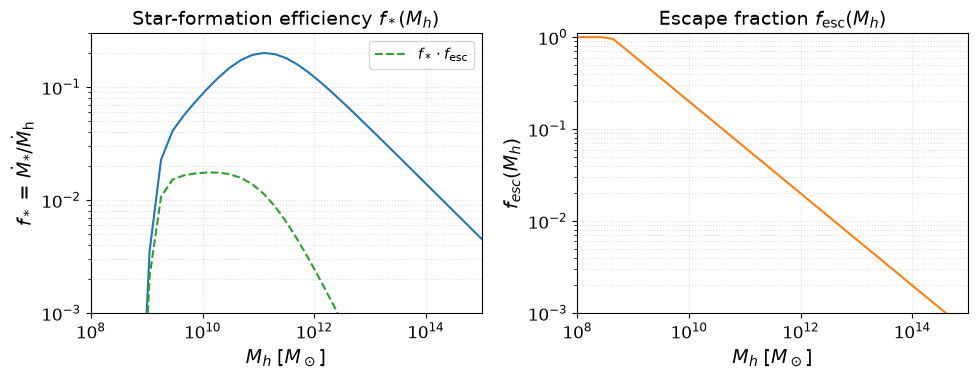

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

beorn.plotting.draw_star_formation_rate(axes[0], parameters, color='C0')
beorn.plotting.draw_f_esc(axes[1], parameters, color='C1')

Mh_grid = parameters.solver.halo_mass_bins
keep = (Mh_grid > parameters.source.halo_mass_min) & (Mh_grid <= parameters.source.halo_mass_max)
Mh_plot = Mh_grid[keep]
from beorn.astro import f_star_Halo, f_esc as f_esc_func
combined = f_star_Halo(parameters, Mh_plot) * f_esc_func(parameters, Mh_plot)
axes[0].loglog(Mh_plot, combined, color='C2', ls='--', label=r'$f_* \cdot f_\mathrm{esc}$')
axes[0].legend(fontsize=11)

axes[0].set_title(r'Star-formation efficiency $f_*(M_h)$')
axes[1].set_title(r'Escape fraction $f_\mathrm{esc}(M_h)$')

for ax in axes:
    ax.set_xlabel(r'$M_h \; [M_\odot]$')
    ax.grid(True, which='both', ls=':', alpha=0.4)
    ax.set_xlim(1e8,1e15)
axes[0].set_ylim(1e-3,3e-1)
axes[1].set_ylim(1e-3,1.1)

plt.tight_layout()
plt.show()

---
<a id="sec2"></a>
## 2. Precompute radiation profiles

The 1D radiation profiles depend only on the astrophysical parameters — not
on the density field or halo catalogues — and cached results are reused
automatically.


In [ ]:
cache_handler = beorn.io.Handler(CACHE_ROOT)

solver = beorn.precomputation.RadiationProfileSolver(
    parameters, parameters.cosmo_sim.snapshot_redshifts
)
profiles = solver.get_or_compute_profiles(cache_handler)

INFO:beorn.io.handler:Using persistence directory at cache


INFO:beorn.precomputation.solver:Loaded radiation profiles from cache (z=20.00→5.50, 30 steps).


### Inspecting the pre-computed 1D profiles

The figure below mirrors Figure 2 of [Schaeffer et al. 2023](https://arxiv.org/abs/2305.15466). Each panel corresponds to a different halo mass and shows how the radial profile evolves with redshift (blue → red):

1. **Halo mass accretion history** — exponential MAR model (grey) vs. Behroozi et al. 2020 simulations (gold).
2. **Lyman-α flux profile** $\rho_\alpha(r)$ — sets the WF coupling $x_\alpha$.
3. **Kinetic temperature profile** $T_k(r)$ — driven by X-ray heating.
4. **Ionization fraction** $x_\mathrm{HII}(r)$ — sharp bubble front expanding with time.

Adjust `mass_index` and the redshift/alpha lists to explore different halo masses or accretion histories.


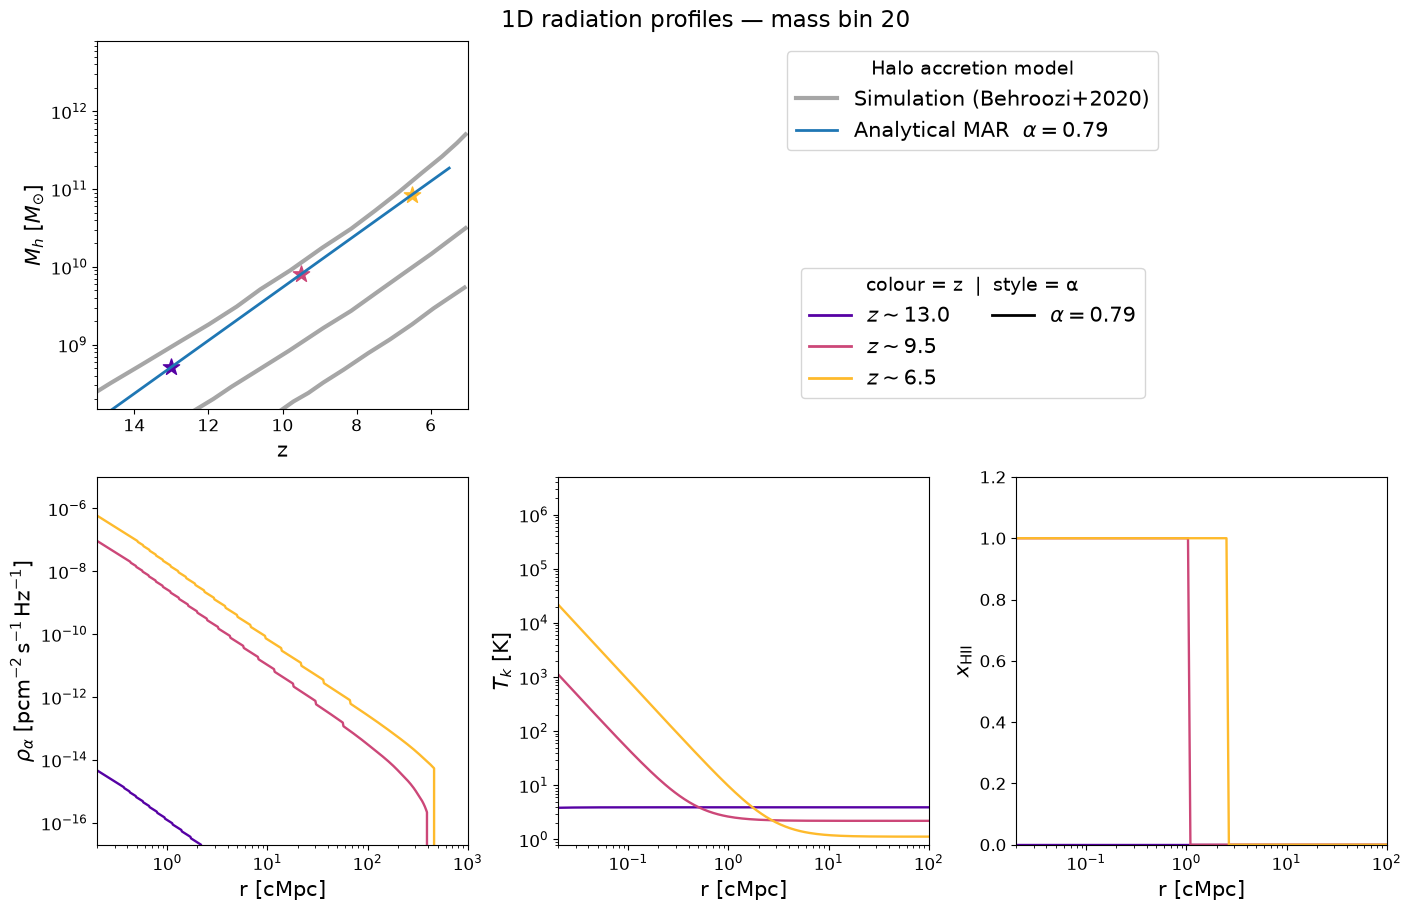

In [ ]:
# Select a mid-range mass bin and three representative redshifts
mass_index = 20   # index into the 40-bin halo mass grid (~10^10–10^11 Msol depending on z)
profile_redshifts = [13.0, 9.5, 6.5]
# Use only the first alpha value to match the number of alpha bins in the cached profiles
profile_alphas = [parameters.solver.halo_mass_accretion_alpha[0]]

beorn.plotting.plot_1D_profiles(
    parameters,
    profiles,
    mass_index=mass_index,
    redshifts=profile_redshifts,
    alphas=profile_alphas,
    label=f"1D radiation profiles — mass bin {mass_index}",
    fontsize=15,
)


---
<a id="sec3"></a>
## 3. Cosmological inputs: LPT density field + CHMF halo catalogues

`LPTHaloLoader` wires together:

1. an **LPT solver** (Zel'dovich by default) that generates fixed-amplitude
   Gaussian initial conditions from the E&H power spectrum and displaces them
   to each snapshot redshift, and
2. a **`CHMFSampler`** that, in every grid cell, Poisson-samples halos from
   the EPS conditional mass function given the cell's linear overdensity
   `get_linear_density(z, R_tophat)`.

There is no `generate()` step and no HDF5 input caching: fields and catalogues
are computed on demand and are fully deterministic given the seed (the
per-snapshot sampling seed is derived from `seed` and the redshift index).


In [ ]:
SEED = parameters.cosmo_sim.random_seed

loader = beorn.load_input_data.LPTHaloLoader(
    parameters,
    seed=SEED,
    n_mass_bins=40,
    # R_env=2.0,   # optional: condition CHMF on a larger smoothed region (Mpc/h)
                   # to raise the environment mass cap M_env
)
# For 2LPT-accurate density fields instead of Zel'dovich:
# lpt2 = beorn.lpt.SecondOrderLPT(parameters, seed=SEED, verbose=False)
# loader = beorn.load_input_data.LPTHaloLoader(parameters, lpt_solver=lpt2, seed=SEED)

chmf = loader.sampler.chmf   # analytical (C)HMF, used as theory reference below

cell = parameters.simulation.Lbox / parameters.simulation.Ncell
M_env = chmf.rho_m * cell**3
print(f'Cell size          : {cell:.3f} Mpc/h')
print(f'M_env (cell mass)  : {M_env:.3e} Msun  — CHMF cap with default cell conditioning')
print(f'halo_mass_min      : {parameters.source.halo_mass_min:.1e} Msun')

input_tag = (f"lpt_native_N{parameters.simulation.Ncell}"
             f"_L{parameters.simulation.Lbox:.0f}_seed{SEED}")
output_handler = beorn.io.Handler(OUTPUT_ROOT, input_tag=input_tag)

INFO:beorn.io.handler:Using persistence directory at output


Cell size          : 0.781 Mpc/h
M_env (cell mass)  : 6.193e+10 Msun  — CHMF cap with default cell conditioning
halo_mass_min      : 1.0e+08 Msun


### 3.1 GPU acceleration test

The LPT solvers accept a `backend=` argument (GPU execution is opt-in — the
default is numpy float64). With `TorchBackend('mps')` / `TorchBackend('cuda')`
the FFTs and k-space algebra of the field generation run on the GPU; the
Poisson catalogue draws stay on the CPU. A GPU-backed solver can be handed
straight to the loader via `LPTHaloLoader(parameters, lpt_solver=..., seed=...)`.


In [ ]:
if _TORCH_AVAILABLE and torch_gpu is not None:
    import time
    from beorn.lpt import TorchBackend

    lpt_gpu = beorn.lpt.ZeldovichApproximation(parameters, verbose=False,
                                               backend=TorchBackend(torch_gpu))
    lpt_gpu.generate_initial_conditions(grf=loader.lpt_solver.delta_k)  # same ICs

    z_gpu_test = 7.0
    d_cpu = loader.lpt_solver.get_density(z_gpu_test)
    d_gpu = lpt_gpu.get_density(z_gpu_test)
    print(f'density field torch-{torch_gpu} vs numpy: max|Δδ|/std = '
          f'{np.max(np.abs(d_gpu - d_cpu)) / d_cpu.std():.2e}'
          + ('  (float32 on MPS)' if torch_gpu == 'mps' else ''))

    def bench(fn, n=3):
        fn()
        ts = []
        for _ in range(n):
            t0 = time.perf_counter()
            fn()
            ts.append(time.perf_counter() - t0)
        return min(ts)

    t_c = bench(lambda: loader.lpt_solver.get_displacement(z_gpu_test))
    t_g = bench(lambda: lpt_gpu.get_displacement(z_gpu_test))
    N_ = parameters.simulation.Ncell
    print(f'get_displacement {N_}³:  numpy {t_c*1e3:6.0f} ms   '
          f'torch-{torch_gpu} {t_g*1e3:6.0f} ms   ({t_c/t_g:.1f}×)')
else:
    print('GPUs not available — GPU LPT test skipped.' if _TORCH_AVAILABLE
          else 'torch is not installed — GPU test skipped.')


density field torch-cuda vs numpy: max|Δδ|/std = 0.00e+00
get_displacement 128³:  numpy     34 ms   torch-cuda      1 ms   (36.7×)


---
<a id="sec4"></a>
## 4. Inspect the halo catalogue and density field

Two sanity checks: the sampled catalogue must reproduce the analytical mass
function it was drawn from, and the halos must trace the LPT density field.

The sampler supports two calibrations (`hmf_model` on `LPTHaloLoader`):

- **`'PS'`** (default) — pure EPS conditional sampling; by construction its
  volume average is the **Press–Schechter** mass function.
- **`'ST'`** — the hybrid prescription of
  [Barkana & Loeb (2004)](https://arxiv.org/abs/astro-ph/0310338) (see also
  appendix A of [Ghara et al. 2015](https://arxiv.org/abs/1406.4157)): each
  mass bin is rescaled by the unconditional ST/PS ratio, so the δ-dependence
  keeps the EPS shape while the volume average matches the
  simulation-calibrated **Sheth–Tormen** mass function — the choice made by
  21cmFAST-family codes. Pass `hmf_model='ST'` to the loader in section 3 to
  run the whole pipeline on ST-calibrated catalogues.


INFO:beorn.structs.halo_catalog:No alpha values provided, using default value of 0.79 for all halos.


Number of halos at z=7.0 (PS): 24,999,187
Mass range: 1.08e+08 — 5.71e+10 Msol


INFO:beorn.structs.halo_catalog:No alpha values provided, using default value of 0.79 for all halos.


Number of halos at z=7.0 (ST): 20,381,806


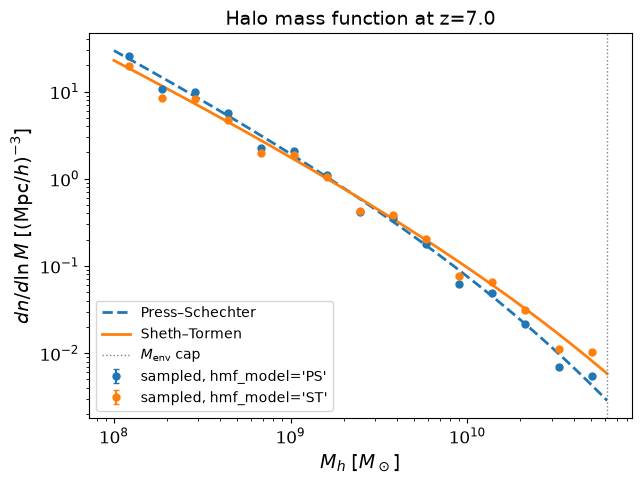

In [ ]:
z_target = 7.0
z_index = int(np.argmin(np.abs(loader.redshifts - z_target)))

halo_catalog = loader.load_halo_catalog(z_index)
print(f"Number of halos at z={z_target} (PS): {len(halo_catalog.masses):,}")
print(f"Mass range: {halo_catalog.masses.min():.2e} — {halo_catalog.masses.max():.2e} Msol")

# same box and seed, Sheth-Tormen calibration (Barkana & Loeb 2004 hybrid)
loader_st = beorn.load_input_data.LPTHaloLoader(parameters, seed=SEED,
                                                n_mass_bins=40, hmf_model='ST')
halo_catalog_st = loader_st.load_halo_catalog(z_index)
print(f"Number of halos at z={z_target} (ST): {len(halo_catalog_st.masses):,}")

fig, ax = plt.subplots(figsize=(7, 5))
for cat, color, lbl in [(halo_catalog, 'C0', "hmf_model='PS'"),
                        (halo_catalog_st, 'C1', "hmf_model='ST'")]:
    edges, hmf_meas, hmf_err = cat.halo_mass_function(bin_count=15)
    Mb = np.sqrt(edges[:-1] * edges[1:])
    msk = hmf_meas > 0
    ax.errorbar(Mb[msk], hmf_meas[msk], yerr=hmf_err[msk], fmt='o', ms=5,
                color=color, capsize=2, label=f'sampled, {lbl}')

M_plot = np.logspace(np.log10(parameters.source.halo_mass_min), np.log10(M_env), 200)
ax.loglog(M_plot, chmf.hmf_ps(M_plot, z_target), 'C0--', lw=2, label='Press–Schechter')
ax.loglog(M_plot, chmf.hmf_st(M_plot, z_target), 'C1-', lw=2, label='Sheth–Tormen')
ax.axvline(M_env, color='grey', ls=':', lw=1, label=r'$M_\mathrm{env}$ cap')
ax.set_xlabel(r'$M_h\;[M_\odot]$')
ax.set_ylabel(r'$dn/d\ln M\;[(\mathrm{Mpc}/h)^{-3}]$')
ax.set_title(f'Halo mass function at z={z_target}', fontsize=14)
ax.legend(fontsize=10)
plt.show()


366,030 halos in the slab; showing the 20,653 with M ≥ 1e9 Msun


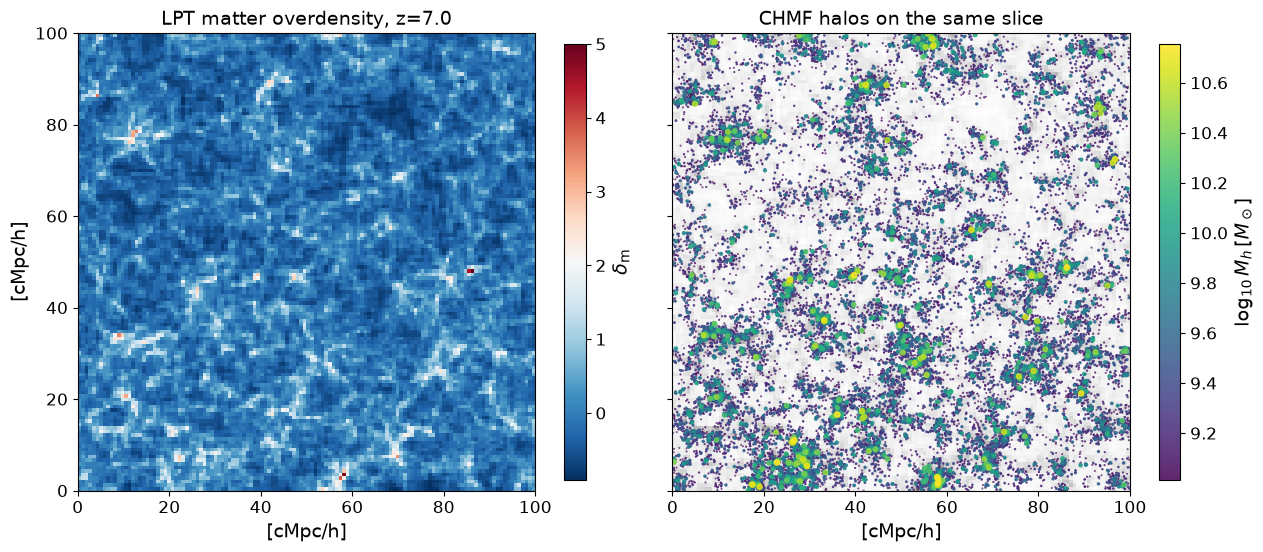

In [ ]:
delta_m = loader.load_density_field(z_index)

Lbox = parameters.simulation.Lbox  # cMpc/h
extent = [0, Lbox, 0, Lbox]
mid = parameters.simulation.Ncell // 2

# halos within one cell of the slice plane; plotting every halo saturates the
# panel (~2e5 in the slab), so show M >= 1e9 Msun, massive halos drawn on top
slab = (np.abs(halo_catalog.positions[:, 1] - (mid + 0.5) * cell) < cell)
pos = halo_catalog.positions[slab]
mass = halo_catalog.masses[slab]
show = mass >= 1e9
order = np.argsort(mass[show])
pos_s, mass_s = pos[show][order], mass[show][order]
print(f'{slab.sum():,} halos in the slab; showing the {show.sum():,} with M ≥ 1e9 Msun')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

im = axes[0].imshow(delta_m[:, mid, :], origin='lower', cmap='RdBu_r', extent=extent)
axes[0].set_title(f'LPT matter overdensity, z={z_target}')
axes[0].set_xlabel('[cMpc/h]')
axes[0].set_ylabel('[cMpc/h]')
fig.colorbar(im, ax=axes[0], label=r'$\delta_\mathrm{m}$', shrink=0.9)

axes[1].imshow(delta_m[:, mid, :], origin='lower', cmap='Greys', extent=extent)
sc = axes[1].scatter(pos_s[:, 2], pos_s[:, 0], s=4*(np.log10(mass_s)-8.8)**2,
                     c=np.log10(mass_s), cmap='viridis', alpha=0.85)
axes[1].set_title('CHMF halos on the same slice')
axes[1].set_xlabel('[cMpc/h]')
fig.colorbar(sc, ax=axes[1], label=r'$\log_{10} M_h\,[M_\odot]$', shrink=0.9)

plt.tight_layout()
plt.show()


---
<a id="sec5"></a>
## 5. Paint the 3D signal maps

`PaintingCoordinator` consumes the loader through the generic
`load_density_field` / `load_halo_catalog` interface and paints the
precomputed 1D radiation profiles around every halo at each snapshot redshift.


In [ ]:
p = beorn.painting.PaintingCoordinator(
    parameters,
    loader=loader,
    output_handler=output_handler,
)

# paint_full() returns immediately — grid fields are lazy, backed by per-z HDF5 files.
multi_z_quantities = p.paint_full(profiles)

INFO:beorn.painting.coordinator:============================================================
BEoRN model summary
  Cosmology   : Om=0.315, Ob=0.049, h0=0.673, sigma_8=0.83
  Grid        : Ncell=128, Lbox=100 Mpc/h (=100.000 Mpc/h internally)
  Profile z   : z=20.0 -> 5.2 (60 steps)
  Snapshot z  : z=20.0 -> 5.5 (30 snapshots)
  1D RT bins  : 1.0e+07 - 1.0e+15 Msun at z=5.2 (40 bins, traced back via exp. accretion)
  Source      : f_st=0.2, Nion=2000, f0_esc=0.2
  X-ray       : norm=1.02e+40, E=[500, 10000] eV
  Lyman-alpha : n_phot=9690, star-forming above 1.0e+08 Msun
  Beorn hash  : 80da1d60
INFO:beorn.painting.coordinator:Painting profiles onto grid for 30 of 30 redshift snapshots. Using 1 processes on a single node.
Painting redshift snapshots:   0%|          | 0/30 [00:00<?, ?snapshot/s]

INFO:beorn.structs.halo_catalog:No alpha values provided, using default value of 0.79 for all halos.
INFO:beorn.painting.coordinator:Painting 2081 halos at zgrid=20.00 (z_index=0).
INFO:beorn.painting.coordinator:Profile painting took 0:00:00.421576.
INFO:beorn.painting.spread:Universe not fully ionized : xHII is 0.0.
INFO:beorn.painting.coordinator:Redistributing excess photons from the overlapping regions took 0:00:00.040774.
INFO:beorn.painting.coordinator:Postprocessing of the grids took 0:00:00.058996.
INFO:beorn.painting.coordinator:Current snapshot took 0:00:05.093591.
INFO:beorn.structs.base_struct:Data written to output/igm_data_lpt_native_N128_L100_seed12345_80da1d60/CoevalCube_z20.000.h5 (56.02 MB)
Painting redshift snapshots:   3%|▎         | 1/30 [00:05<02:35,  5.35s/snapshot, z=20.000]INFO:beorn.structs.halo_catalog:No alpha values provided, using default value of 0.79 for all halos.
INFO:beorn.painting.coordinator:Painting 3600 halos at zgrid=19.50 (z_index=1).
INFO:beor

---
<a id="sec6"></a>
## 6. Visualise the 3D maps at a single redshift


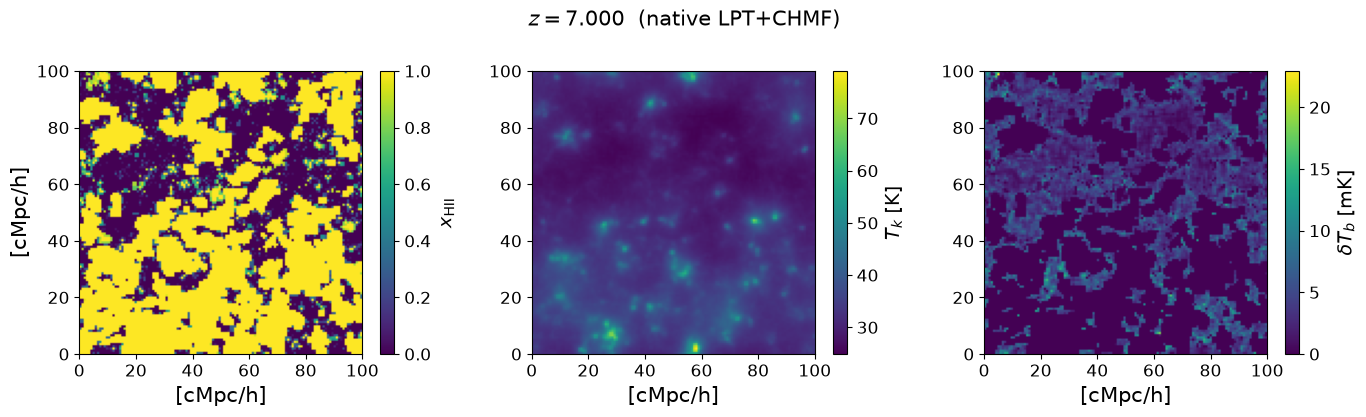

In [ ]:
snap = multi_z_quantities.snapshot(z_target)

xHII_grid = snap.Grid_xHII[:]
dTb_grid  = snap.Grid_dTb
Tk_grid   = snap.Grid_Temp[:]

mid = xHII_grid.shape[1] // 2
extent = [0, Lbox, 0, Lbox]

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
for ax, grid, label in zip(axs,
                            [xHII_grid, Tk_grid, dTb_grid],
                            [r'$x_\mathrm{HII}$', r'$T_k$ [K]', r'$\delta T_b$ [mK]']):
    im = ax.imshow(grid[:, mid, :], origin='lower', cmap='viridis', extent=extent)
    ax.set_xlabel('[cMpc/h]', fontsize=15)
    fig.colorbar(im, ax=ax, label=label)
axs[0].set_ylabel('[cMpc/h]', fontsize=15)
fig.suptitle(f'$z={snap.z:.3f}$  (native LPT+CHMF)', fontsize=15)
plt.tight_layout()
plt.show()

---
<a id="sec7"></a>
## 7. Global history and power spectra


Power spectrum: 100%|██████████| 30/30 [00:05<00:00,  5.26snapshot/s]
INFO:beorn.structs.temporal_cube:TemporalCube.power_spectrum: k_Nyquist = 4.021


k=0.12 h/Mpc


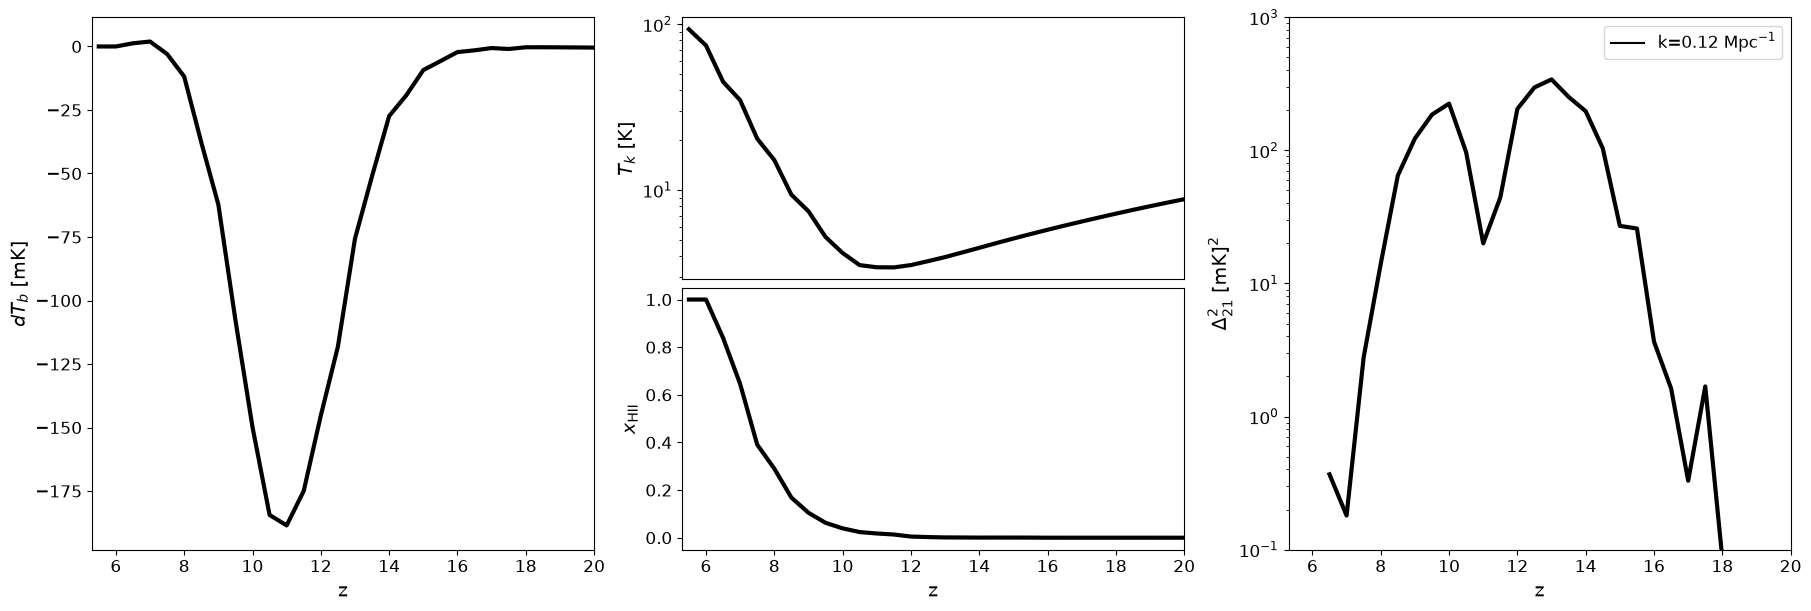

In [ ]:
fig = plt.figure(constrained_layout=True, figsize=(18, 6))
gs = gridspec.GridSpec(2, 3, figure=fig)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)
ax4 = fig.add_subplot(gs[:, 2])

beorn.plotting.draw_dTb_signal(ax1, multi_z_quantities, color='k', lw=3)
beorn.plotting.draw_Temp_signal(ax2, multi_z_quantities, color='k', lw=3)
beorn.plotting.draw_xHII_signal(ax3, multi_z_quantities, color='k', lw=3)
kplot = beorn.plotting.draw_dTb_power_spectrum_of_z(
                    ax4, multi_z_quantities, parameters, k_value=0.1, color='k', lw=3)
ax4.plot([], [], color='k', label=f'k={kplot:.2f} Mpc$^{{-1}}$')
ax4.legend(loc=0)
ax2.axes.get_xaxis().set_visible(False)
plt.show()

In [ ]:
# Save summary statistics for cheap reuse and cross-run comparison
stats = beorn.structs.StatisticsEstimator(multi_z_quantities, parameters)
saved_path = stats.save(path=f'output/igm_stats_{input_tag}.h5')
print(f"Statistics saved to: {saved_path}")

Power spectrum: 100%|██████████| 30/30 [00:05<00:00,  5.09snapshot/s]
INFO:beorn.structs.temporal_cube:TemporalCube.power_spectrum: k_Nyquist = 4.021


Statistics saved to: output/igm_stats_lpt_native_N128_L100_seed12345.h5


---
<a id="sec8"></a>
## 8. Lightcone


Making lightcone between 0.047619 < z < 0.153697


100%|██████████| 376/376 [00:00<00:00, 5315.58it/s]


...done


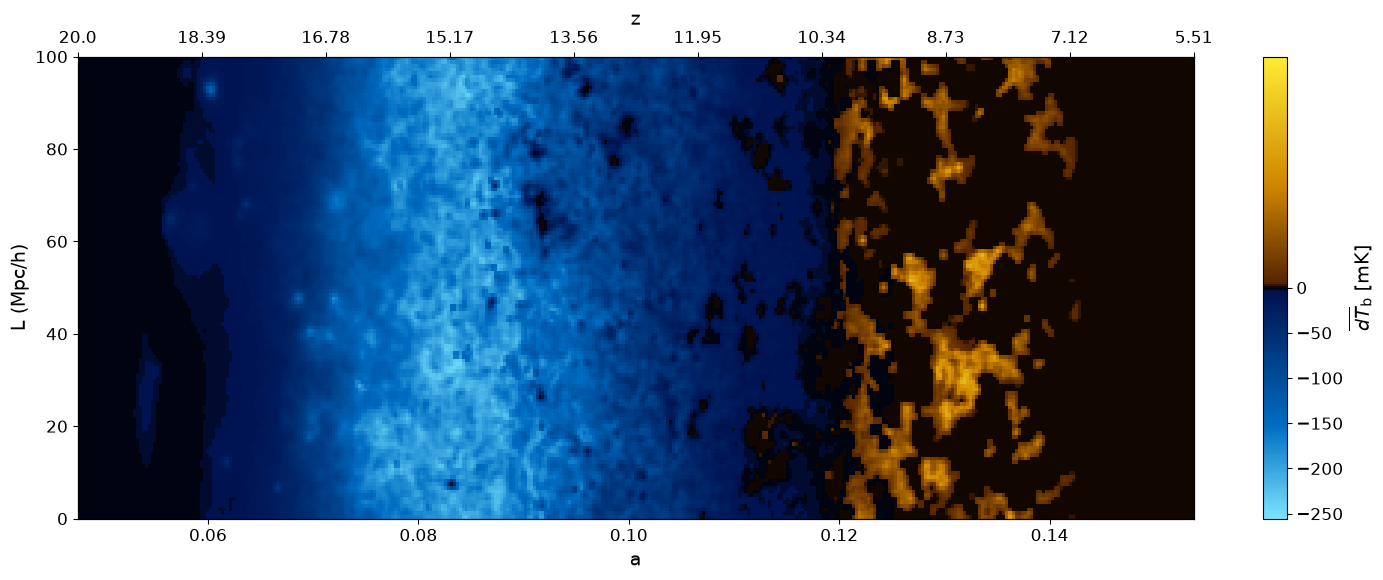

In [ ]:
lightcone = beorn.structs.Lightcone.build(
    parameters,
    multi_z_quantities,
    quantity="Grid_dTb",
)

fig, ax = plt.subplots(figsize=(18, 6))
beorn.plotting.plot_lightcone(lightcone, ax, "", slice_number=30)
fig.show()